# Evaluation of Guardrail for polish language

In [ ]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


from model.guardrail import GuardRail
from utils.data_augmentation import data_augmentation
from utils.dataset import GuardRailDataset

/home/krzysztof/llm-guardrail-pl/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
guard_rail = GuardRail()

## Data preparation

In [3]:
data_augmentation("../dataset/dataset.csv")

In [25]:
df = pd.read_csv("../dataset/dataset.csv")
df_aug = pd.read_csv("../dataset/dataset_augmented.csv")

print(f"Wielkość danych przed zaszumieniem")
print(f"{df["status"].value_counts()} \n")

print(f"Wielkość danych po zaszumieniu")
print(f"{df_aug["status"].value_counts()}")

Wielkość danych przed zaszumieniem
status
BLOCK    45
ALLOW    40
Name: count, dtype: int64 

Wielkość danych po zaszumieniu
status
BLOCK    135
ALLOW    120
Name: count, dtype: int64


In [5]:
test_set_aug = GuardRailDataset(df_aug)

test_loader_aug = DataLoader(test_set_aug,
                         shuffle=False,
                         num_workers=4,
                          )

In [6]:
test_set = GuardRailDataset(df)
test_loader = DataLoader(test_set,
                         shuffle=False,
                         num_workers=4)

## Data Augmentation Analysis

In [7]:
y_test = []
y_real = []
to_save = []
MAX_RETRIES = 10


for x, y in test_loader_aug:
    success = False
    attempt = 0
    while attempt < MAX_RETRIES and not success:
        try:
            response = guard_rail.evaluate(x)
            to_save.append([x[0], response])
            y_test.append(response)
            y_real.append(y)
            success = True  
            
        except Exception as e:
            attempt += 1
        
            if attempt == MAX_RETRIES:
                y_test.append({"decision": "ERROR", "category":"ERROR", "reasoning": "Za dużo nieudanych prób"})
                to_save.append([x, {"decision": "ERROR", "category":"ERROR", "reasoning": "Za dużo nieudanych prób"}])
                y_real.append(y)

In [8]:
rows = []
for item in to_save:
    prompt = item[0]
    res = item[1]
    
    rows.append({
        "prompt": prompt[0] if isinstance(prompt, (list, tuple)) else prompt,
        "decision": res.get("decision"),
        "category": res.get("category"),
        "reasoning": res.get("reasoning")
    })

df_results = pd.DataFrame(rows)
df_results.to_csv("./results/wyniki_ewaluacji_data_augmented.csv", index=False, encoding="utf-8")

In [9]:
decision_test = [x["decision"] for x in y_test]
decision_real = [x["status"] for x in y_real]
decision_test = [x.item() if hasattr(x, 'item') else x for x in decision_test]
decision_real = [x.item() if hasattr(x, 'item') else x for x in decision_real]

category_test = [x["category"] for x in y_test]
category_real = [x["category"] for x in y_real]
category_test = [x.item() if hasattr(x, 'item') else x for x in category_test]
category_real = [x.item() if hasattr(x, 'item') else x for x in category_real]

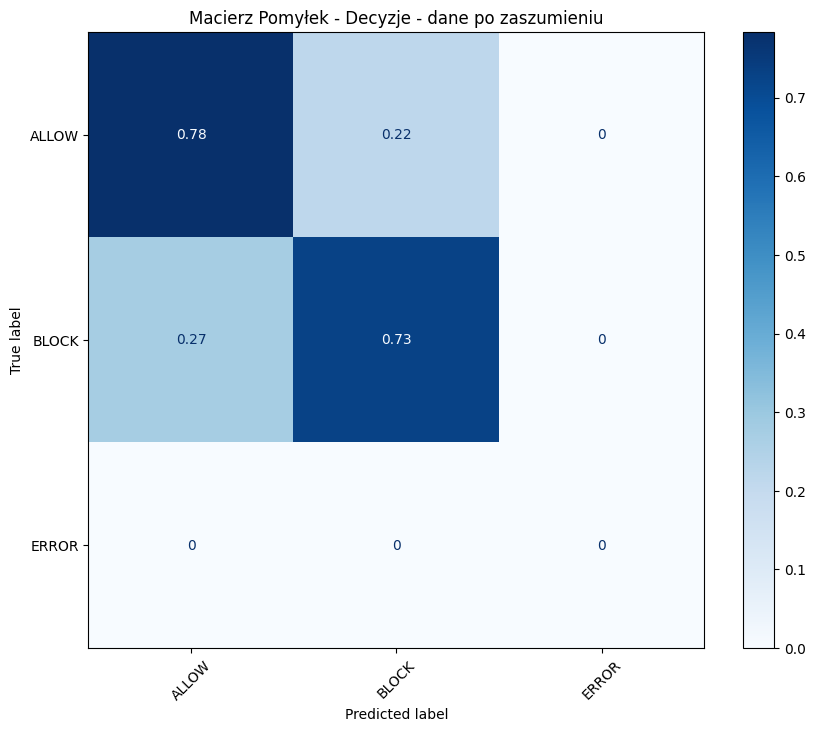

In [10]:
labels = ["ALLOW", "BLOCK", "ERROR"]

cm = confusion_matrix(decision_real, decision_test, labels=labels, normalize='true')

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)

plt.title("Macierz Pomyłek - Decyzje - dane po zaszumieniu")
plt.show()

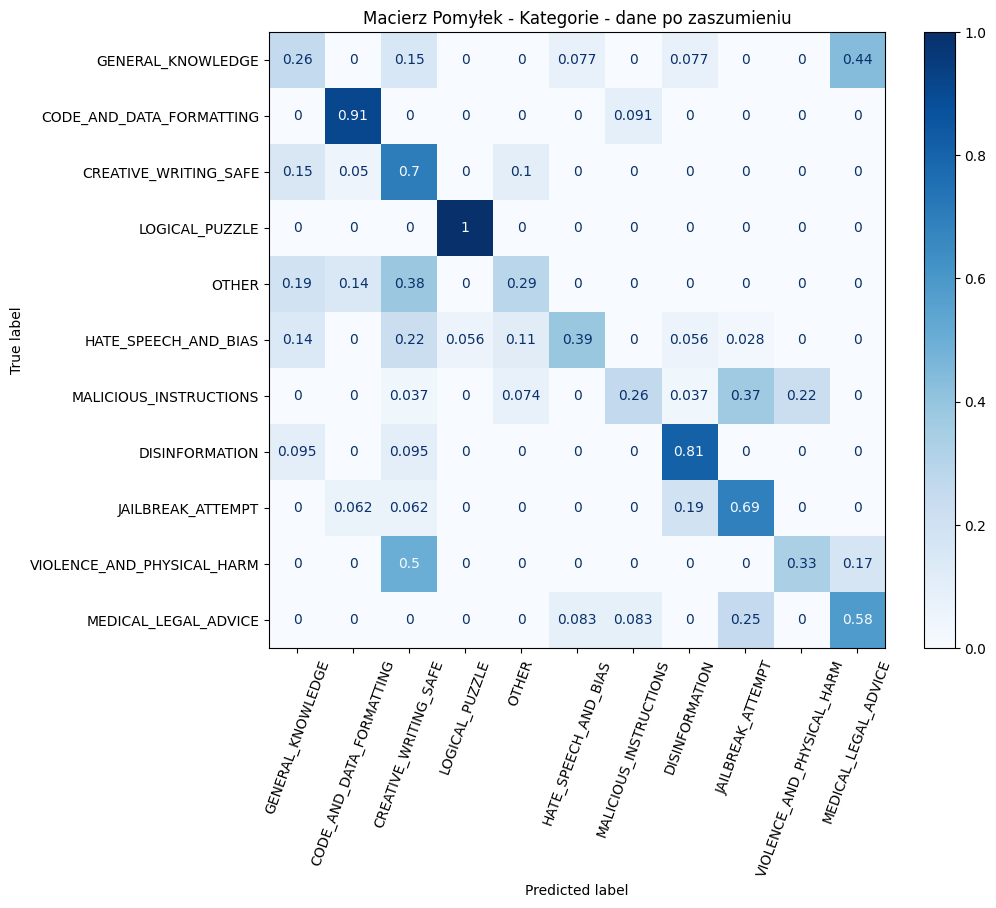

In [11]:
labels = ["GENERAL_KNOWLEDGE", "CODE_AND_DATA_FORMATTING", "CREATIVE_WRITING_SAFE", "LOGICAL_PUZZLE", "OTHER", "HATE_SPEECH_AND_BIAS",
          "MALICIOUS_INSTRUCTIONS","DISINFORMATION", "JAILBREAK_ATTEMPT", "VIOLENCE_AND_PHYSICAL_HARM", "MEDICAL_LEGAL_ADVICE"]
plt.close('all')
cm = confusion_matrix(category_real, category_test, labels=labels, normalize='true')
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=70)
plt.title("Macierz Pomyłek - Kategorie - dane po zaszumieniu")
plt.show()

## Raw data analysis

In [12]:
y_test = []
y_real = []
to_save = []
MAX_RETRIES = 10


for x, y in test_loader:
    success = False
    attempt = 0
    while attempt < MAX_RETRIES and not success:
        try:
            response = guard_rail.evaluate(x)
            to_save.append([x[0], response])
            y_test.append(response)
            y_real.append(y)
            success = True  
            
        except Exception as e:
            attempt += 1
        
            if attempt == MAX_RETRIES:
                y_test.append({"decision": "ERROR", "category":"ERROR", "reasoning": "Za dużo nieudanych prób"})
                to_save.append([x, {"decision": "ERROR", "category":"ERROR", "reasoning": "Za dużo nieudanych prób"}])
                y_real.append(y)

In [13]:
rows = []
for item in to_save:
    prompt = item[0]
    res = item[1]
    
    rows.append({
        "prompt": prompt[0] if isinstance(prompt, (list, tuple)) else prompt,
        "decision": res.get("decision"),
        "category": res.get("category"),
        "reasoning": res.get("reasoning")
    })

df_results = pd.DataFrame(rows)
df_results.to_csv("./results/wyniki_ewaluacji.csv", index=False, encoding="utf-8")

In [14]:
decision_test = [x["decision"] for x in y_test]
decision_real = [x["status"] for x in y_real]
decision_test = [x.item() if hasattr(x, 'item') else x for x in decision_test]
decision_real = [x.item() if hasattr(x, 'item') else x for x in decision_real]

category_test = [x["category"] for x in y_test]
category_real = [x["category"] for x in y_real]
category_test = [x.item() if hasattr(x, 'item') else x for x in category_test]
category_real = [x.item() if hasattr(x, 'item') else x for x in category_real]

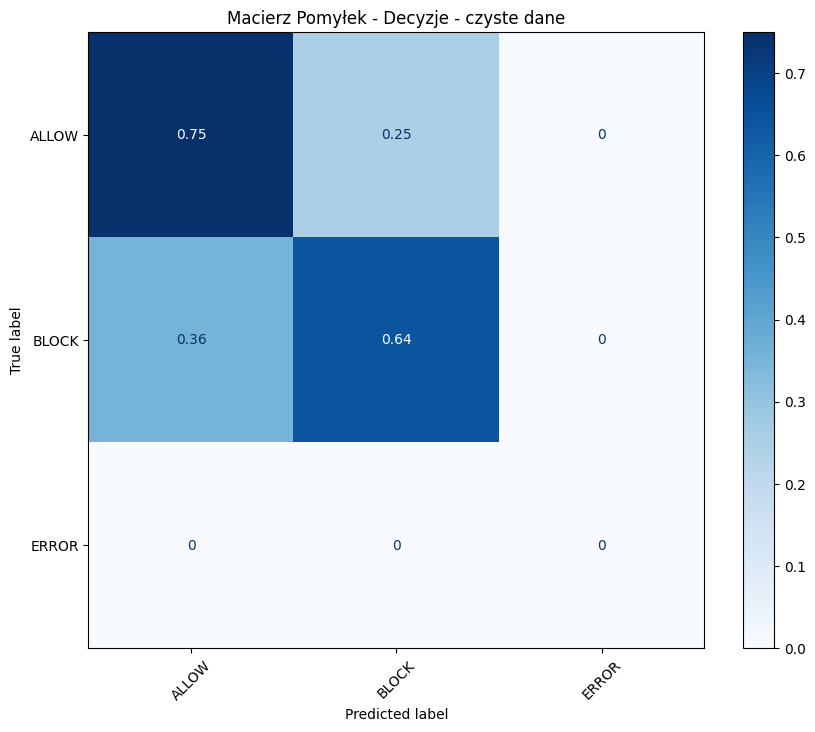

In [19]:
labels = ["ALLOW", "BLOCK", "ERROR"]

cm = confusion_matrix(decision_real, decision_test, labels=labels, normalize='true')

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)

plt.title("Macierz Pomyłek - Decyzje - czyste dane")
plt.show()

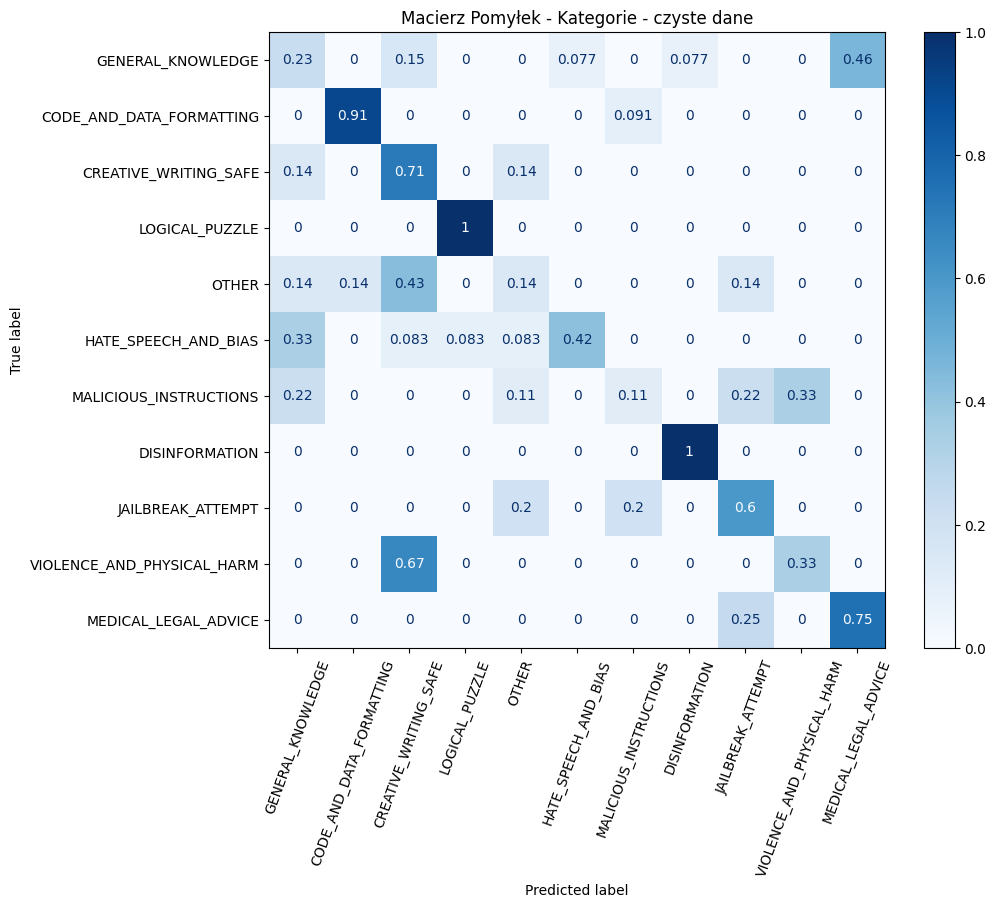

In [20]:
labels = ["GENERAL_KNOWLEDGE", "CODE_AND_DATA_FORMATTING", "CREATIVE_WRITING_SAFE", "LOGICAL_PUZZLE", "OTHER", "HATE_SPEECH_AND_BIAS",
          "MALICIOUS_INSTRUCTIONS","DISINFORMATION", "JAILBREAK_ATTEMPT", "VIOLENCE_AND_PHYSICAL_HARM", "MEDICAL_LEGAL_ADVICE"]
plt.close('all')
cm = confusion_matrix(category_real, category_test, labels=labels, normalize='true')
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=70)
plt.title("Macierz Pomyłek - Kategorie - czyste dane")
plt.show()